# Libraries

In [15]:
import gymnasium as gym
import numpy as np 
import os 
import pickle
import matplotlib.pyplot as plt
import time


# Seed Initialization

In [16]:
SEED = 42
np.random.seed(SEED)

os.makedirs("results/models", exist_ok=True)
os.makedirs("results/logs", exist_ok=True)

# Centralized Config

In [17]:
BINS        = np.array([40, 40])
EPISODES    = 5000
EPSILON     = 1.0  
ALPHA       = 0.1      
GAMMA       = 0.99           
EPS_MIN     = 0.05
EPS_DECAY   = 0.995       
LOG_EVERY   = 500      
AVG_WINDOW  = 100       

# Helpers 

In [18]:
def get_discrete_state(state: np.ndarray, env: gym.Env, bins: np.ndarray) -> tuple:
    """Map a continuous state to a discrete bin index."""
    low  = env.observation_space.low
    high = env.observation_space.high
    scaled   = (state - low) / (high - low)
    discrete = (scaled * bins).astype(int)
    return tuple(np.clip(discrete, 0, bins - 1))


def choose_action(state: tuple, q_table: np.ndarray, epsilon: float, env: gym.Env) -> int:
    """Epsilon-greedy action selection."""
    if np.random.rand() < epsilon:
        return env.action_space.sample()
    return int(np.argmax(q_table[state]))


def log_progress(ep: int, rewards: list, epsilon: float) -> None:
    avg = np.mean(rewards[-AVG_WINDOW:])
    print(f"  Episode {ep:>5} | avg reward: {avg:>8.2f} | epsilon: {epsilon:.4f}")


def moving_average(values, window=100):
    return np.convolve(values, np.ones(window) / window, mode="valid")


class ActionCostWrapper(gym.Wrapper):
    """
    Penalises the agent for taking action 0 (push left) or action 2 (push right).
    Action 1 (no push) is free. That encourages the agent to reach the goal
    with minimal unnecessary actuation.
    """
    def __init__(self, env: gym.Env, action_cost: float = 0.1):
        super().__init__(env)
        self.action_cost = action_cost

    def step(self, action: int):
        obs, reward, terminated, truncated, info = self.env.step(action)
        if action != 1:                   
            reward -= self.action_cost
        return obs, reward, terminated, truncated, info

# Q-learning Training 

In [ ]:
def train_qlearning(alpha=ALPHA, gamma=GAMMA, episodes=EPISODES,
                    epsilon=EPSILON, eps_decay=EPS_DECAY, eps_min=EPS_MIN,
                    bins=BINS) -> tuple[np.ndarray, list]:
    """
    Tabular Q-learning with epsilon-greedy exploration.
    Off-policy: updates towards the greedy/maximum next action.
    Q-table initialised to zero.
    """
    env = gym.make("MountainCar-v0")
    env.reset(seed=SEED)

    q_table = np.zeros((bins[0], bins[1], env.action_space.n))
    rewards  = []

    print("── Q-Learning ──────────────────────────────")
    t0 = time.time()

    for ep in range(1, episodes + 1):
        state, _ = env.reset()
        state     = get_discrete_state(state, env, bins)
        total_reward = 0

        while True:
            action     = choose_action(state, q_table, epsilon, env)
            next_obs, reward, terminated, truncated, _ = env.step(action)
            done       = terminated or truncated
            next_state = get_discrete_state(next_obs, env, bins)

            td_target          = reward + gamma * np.max(q_table[next_state]) * (not done)
            q_table[state + (action,)] += alpha * (td_target - q_table[state + (action,)])

            state        = next_state
            total_reward += reward
            if done:
                break

        epsilon = max(eps_min, epsilon * eps_decay)
        rewards.append(total_reward)

        if ep % LOG_EVERY == 0:
            log_progress(ep, rewards, epsilon)

    env.close()
    print(f"  Completed in {time.time() - t0:.1f}s\n")
    return q_table, rewards

In [20]:
q_table, q_rewards = train_qlearning()

with open("results/models/q_table.pkl", "wb") as f:
    pickle.dump(q_table, f)

np.save("results/logs/rewards.npy", np.array(q_rewards))
print("Q-learning saved.")

── Q-Learning ──────────────────────────────
  Episode   500 | avg reward:  -200.00 | epsilon: 0.0816
  Episode  1000 | avg reward:  -200.00 | epsilon: 0.0500
  Episode  1500 | avg reward:  -200.00 | epsilon: 0.0500
  Episode  2000 | avg reward:  -199.69 | epsilon: 0.0500
  Episode  2500 | avg reward:  -198.39 | epsilon: 0.0500
  Episode  3000 | avg reward:  -197.94 | epsilon: 0.0500
  Episode  3500 | avg reward:  -195.73 | epsilon: 0.0500
  Episode  4000 | avg reward:  -190.92 | epsilon: 0.0500
  Episode  4500 | avg reward:  -194.00 | epsilon: 0.0500
  Episode  5000 | avg reward:  -186.60 | epsilon: 0.0500
  Completed in 13.5s

Q-learning saved.


# SARSA Training

In [ ]:
def train_sarsa(alpha=ALPHA, gamma=GAMMA, episodes=EPISODES,
                epsilon=EPSILON, eps_decay=EPS_DECAY, eps_min=EPS_MIN,
                bins=BINS) -> tuple[np.ndarray, list]:
    """
    Tabular SARSA with epsilon-greedy exploration.
    On-policy: updates towards the action actually taken next (not greedy max).
    Q-table initialised with small negative values (optimistic) to encourage
    exploration — particularly effective on MountainCar where zero-init
    can leave the agent stuck with uniform Q-values early on.
    """
    env = gym.make("MountainCar-v0")
    env.reset(seed=SEED)

    q_table = np.random.uniform(low=-2, high=0, size=(bins[0], bins[1], env.action_space.n))
    rewards  = []

    print("── SARSA ───────────────────────────────────")
    t0 = time.time()

    for ep in range(1, episodes + 1):
        state, _ = env.reset()
        state     = get_discrete_state(state, env, bins)
        action    = choose_action(state, q_table, epsilon, env)
        total_reward = 0

        while True:
            next_obs, reward, terminated, truncated, _ = env.step(action)
            done        = terminated or truncated
            next_state  = get_discrete_state(next_obs, env, bins)
            next_action = choose_action(next_state, q_table, epsilon, env)

            # SARSA update (on-policy) — uses next_action, not argmax
            td_target = reward + gamma * q_table[next_state + (next_action,)] * (not done)
            q_table[state + (action,)] += alpha * (td_target - q_table[state + (action,)])

            state        = next_state
            action       = next_action
            total_reward += reward
            if done:
                break

        epsilon = max(eps_min, epsilon * eps_decay)
        rewards.append(total_reward)

        if ep % LOG_EVERY == 0:
            log_progress(ep, rewards, epsilon)

    env.close()
    print(f"  Completed in {time.time() - t0:.1f}s\n")
    return q_table, rewards

In [22]:
sarsa_table, sarsa_rewards = train_sarsa()

with open("results/models/sarsa_table.pkl", "wb") as f:
    pickle.dump(sarsa_table, f)

np.save("results/logs/sarsa_rewards.npy", np.array(sarsa_rewards))
print("SARSA saved.")

── SARSA ───────────────────────────────────
  Episode   500 | avg reward:  -200.00 | epsilon: 0.0816
  Episode  1000 | avg reward:  -200.00 | epsilon: 0.0500
  Episode  1500 | avg reward:  -199.69 | epsilon: 0.0500
  Episode  2000 | avg reward:  -199.07 | epsilon: 0.0500
  Episode  2500 | avg reward:  -196.15 | epsilon: 0.0500
  Episode  3000 | avg reward:  -195.12 | epsilon: 0.0500
  Episode  3500 | avg reward:  -197.14 | epsilon: 0.0500
  Episode  4000 | avg reward:  -192.52 | epsilon: 0.0500
  Episode  4500 | avg reward:  -195.23 | epsilon: 0.0500
  Episode  5000 | avg reward:  -192.88 | epsilon: 0.0500
  Completed in 11.7s

SARSA saved.


# Q-learning with Action Cost 

In [23]:
def train_qlearning_action_cost(action_cost=0.1,
                                alpha=ALPHA, gamma=GAMMA, episodes=EPISODES,
                                epsilon=EPSILON, eps_decay=EPS_DECAY, eps_min=EPS_MIN,
                                bins=BINS) -> tuple[np.ndarray, list]:
    """
    Q-learning with an actuation penalty applied via ActionCostWrapper.
    Penalising push-left and push-right nudges the agent towards
    efficient trajectories that reach the goal with less unnecessary force.
    Rewards logged here reflect the shaped signal (including penalty),
    so curves will sit lower than the baseline — this is expected.
    """
    env = gym.make("MountainCar-v0")
    env = ActionCostWrapper(env, action_cost=action_cost)
    env.reset(seed=SEED)

    q_table  = np.zeros((bins[0], bins[1], env.action_space.n))
    rewards  = []

    print(f"── Q-Learning + Action Cost (cost={action_cost}) ──")
    t0 = time.time()

    for ep in range(1, episodes + 1):
        state, _ = env.reset()
        state     = get_discrete_state(state, env, bins)
        total_reward = 0

        while True:
            action     = choose_action(state, q_table, epsilon, env)
            next_obs, reward, terminated, truncated, _ = env.step(action)
            done       = terminated or truncated
            next_state = get_discrete_state(next_obs, env, bins)

            # Bellman update — reward already includes actuation penalty
            td_target          = reward + gamma * np.max(q_table[next_state]) * (not done)
            q_table[state + (action,)] += alpha * (td_target - q_table[state + (action,)])

            state        = next_state
            total_reward += reward
            if done:
                break

        epsilon = max(eps_min, epsilon * eps_decay)
        rewards.append(total_reward)

        if ep % LOG_EVERY == 0:
            log_progress(ep, rewards, epsilon)

    env.close()
    print(f"  Completed in {time.time() - t0:.1f}s\n")
    return q_table, rewards

In [24]:
ac_table, ac_rewards = train_qlearning_action_cost(action_cost=0.1)

with open("results/models/ac_q_table.pkl", "wb") as f:
    pickle.dump(ac_table, f)

np.save("results/logs/qlearning_action_cost_rewards.npy", np.array(ac_rewards))
print("Q-learning with action cost saved.")

── Q-Learning + Action Cost (cost=0.1) ──
  Episode   500 | avg reward:  -213.41 | epsilon: 0.0816
  Episode  1000 | avg reward:  -213.77 | epsilon: 0.0500
  Episode  1500 | avg reward:  -214.03 | epsilon: 0.0500
  Episode  2000 | avg reward:  -214.11 | epsilon: 0.0500
  Episode  2500 | avg reward:  -213.93 | epsilon: 0.0500
  Episode  3000 | avg reward:  -212.20 | epsilon: 0.0500
  Episode  3500 | avg reward:  -209.73 | epsilon: 0.0500
  Episode  4000 | avg reward:  -209.66 | epsilon: 0.0500
  Episode  4500 | avg reward:  -202.82 | epsilon: 0.0500
  Episode  5000 | avg reward:  -202.15 | epsilon: 0.0500
  Completed in 14.3s

Q-learning with action cost saved.


# Plots

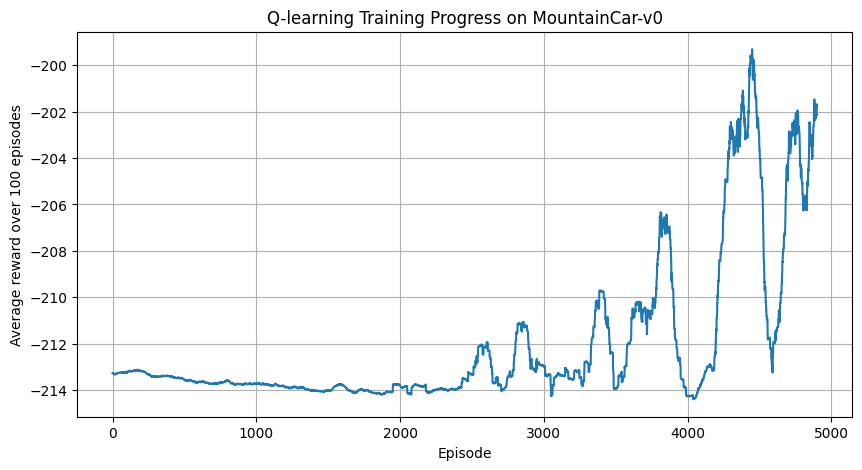

In [25]:
avg_rewards = moving_average(ac_rewards, window=100)

plt.figure(figsize=(10, 5))
plt.plot(avg_rewards)
plt.title("Q-learning Training Progress on MountainCar-v0")
plt.xlabel("Episode")
plt.ylabel("Average reward over 100 episodes")
plt.grid(True)
plt.show()

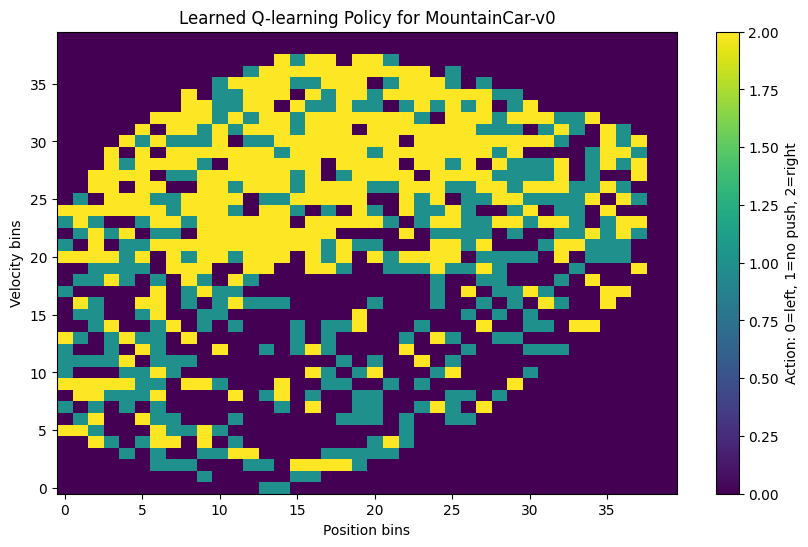

In [26]:
with open("results/models/q_table.pkl", "rb") as f:
    q_table = pickle.load(f)

policy = np.argmax(q_table, axis=2)

plt.figure(figsize=(10, 6))
plt.imshow(policy.T, origin="lower", aspect="auto")
plt.title("Learned Q-learning Policy for MountainCar-v0")
plt.xlabel("Position bins")
plt.ylabel("Velocity bins")
plt.colorbar(label="Action: 0=left, 1=no push, 2=right")
plt.show()

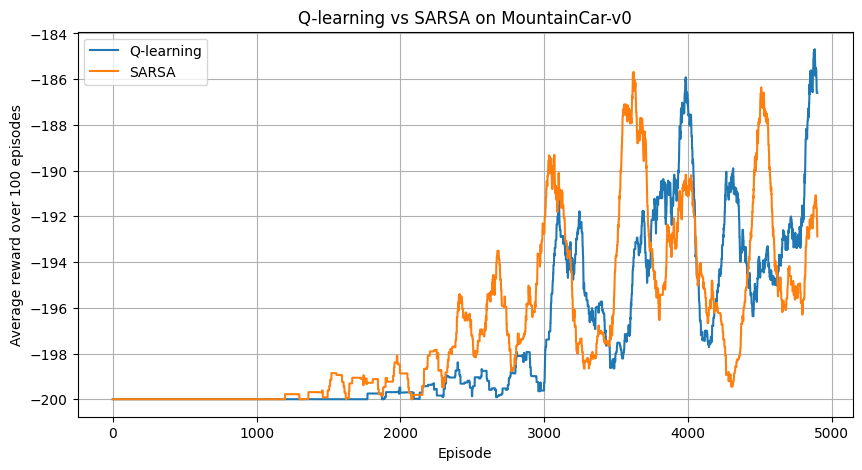

In [27]:
q_rewards = np.load("results/logs/rewards.npy")
sarsa_rewards = np.load("results/logs/sarsa_rewards.npy")

q_avg = moving_average(q_rewards, window=100)
sarsa_avg = moving_average(sarsa_rewards, window=100)

plt.figure(figsize=(10, 5))
plt.plot(q_avg, label="Q-learning")
plt.plot(sarsa_avg, label="SARSA")
plt.title("Q-learning vs SARSA on MountainCar-v0")
plt.xlabel("Episode")
plt.ylabel("Average reward over 100 episodes")
plt.legend()
plt.grid(True)
plt.show()

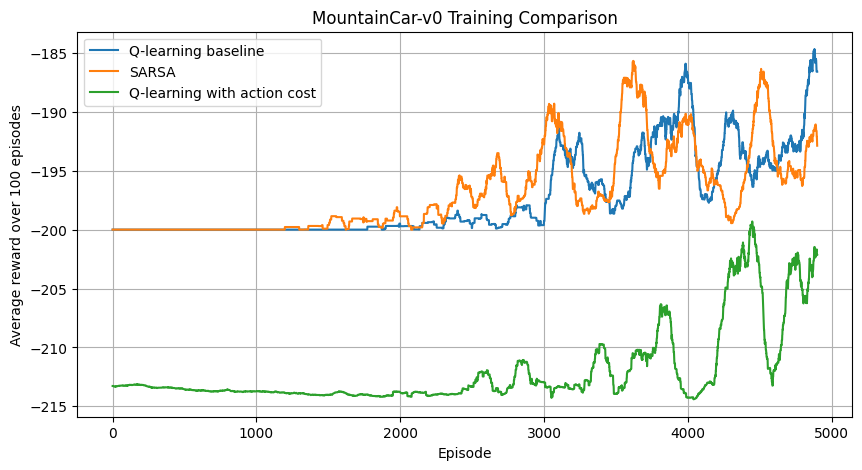

In [28]:
ac_avg = moving_average(ac_rewards, window=100)

plt.figure(figsize=(10, 5))
plt.plot(q_avg, label="Q-learning baseline")
plt.plot(sarsa_avg, label="SARSA")
plt.plot(ac_avg, label="Q-learning with action cost")
plt.title("MountainCar-v0 Training Comparison")
plt.xlabel("Episode")
plt.ylabel("Average reward over 100 episodes")
plt.legend()
plt.grid(True)
plt.show()